2. Configuración del entorno

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

3. EDA 

3.1 Carga los datos y realiza una inspección inicial (estructura, nombres de variables, tipos de datos).

In [61]:
data = pd.read_csv(r'heart_disease_uci.csv')
data = pd.DataFrame(data)
data.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
data.shape

(920, 16)

In [5]:
data.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [6]:
data.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

3.2 Identifica y clasifica las variables en categóricas (nominales, ordinales) y cuantitativas (discretas, continuas).

VARIABLES CUANTITATIVAS: Se expresan en números y permiten comparar magnitudes.

Continuas: 

    age (Edad)
    trestbps (Presión arterial en reposo)
    chol (Colesterol sérico)
    thalch (Frecuencia cardíaca máxima)
    oldpeak (Depresión del ST)


Discretas: 

    ca (Número de vasos principales)


VARIABLES CATEGORICAS: Describen cualidades o etiquetas y no se expresan numéricamente de forma natural.

Nominales:

    sex (sexo/genero)
    cp (tipo de dolor de pecho)
    fbs (nivel de azucar en sangre en ayunas)
    restecg (resultados de electrogardiogramas en reposo)
    exang (angina inducida por ejercicio)
    slope (relación entre indice de pendiente de segmento ST y capacidad del ejercicio)
    thal (talasemia)



3.3 Calcula medidas de resumen para las variables numéricas clave (e.g., age, trestbps, chol, thalach):

In [7]:
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [8]:
#Definición de función que calcula cada medida estadística.
def resumen(data, var):
    media = data[var].mean()
    mediana = data[var].median()
    std = data[var].std()
    qone = data[var].quantile(0.25)
    qtwo = data[var].quantile(0.50)
    qthree = data[var].quantile(0.75)
    qfour = data[var].quantile(1)
    iqr = qthree-qone
    coef_var = std/media
    resultado = {
        "Media" : media,
        "Mediana" : mediana,
        "Std" : std,
        "Q1" : qone,
        "Q2" : qtwo,
        "Q3" : qthree,
        "Q4" : qfour,
        "IQR" : iqr,
        "Coeficiente de Variación" : coef_var
    }
    return resultado

In [9]:
#Ciclo for para ejecutar función predefinida, por variable.
var = ["age","trestbps", "chol", "thalch", "oldpeak"]
for v in var:
    print(f"Resumen estadístico de {v}")
    print(resumen(data,v))  

Resumen estadístico de age
{'Media': np.float64(53.51086956521739), 'Mediana': np.float64(54.0), 'Std': np.float64(9.424685209576857), 'Q1': np.float64(47.0), 'Q2': np.float64(54.0), 'Q3': np.float64(60.0), 'Q4': np.float64(77.0), 'IQR': np.float64(13.0), 'Coeficiente de Variación': np.float64(0.176126556831418)}
Resumen estadístico de trestbps
{'Media': np.float64(132.13240418118468), 'Mediana': np.float64(130.0), 'Std': np.float64(19.066069518587476), 'Q1': np.float64(120.0), 'Q2': np.float64(130.0), 'Q3': np.float64(140.0), 'Q4': np.float64(200.0), 'IQR': np.float64(20.0), 'Coeficiente de Variación': np.float64(0.14429518358300208)}
Resumen estadístico de chol
{'Media': np.float64(199.13033707865168), 'Mediana': np.float64(223.0), 'Std': np.float64(110.7808103532305), 'Q1': np.float64(175.0), 'Q2': np.float64(223.0), 'Q3': np.float64(268.0), 'Q4': np.float64(603.0), 'IQR': np.float64(93.0), 'Coeficiente de Variación': np.float64(0.5563231197136715)}
Resumen estadístico de thalch
{'M

3.4 Tendencia central: media, mediana.

3.5 Dispersión: desviación estándar, rango intercuartílico (IQR), coeficiente de variación.

In [10]:
resumen_general = pd.DataFrame({
    "Media": data[var].mean(),
    "Mediana": data[var].median(),
    "Desviación Estándar": data[var].std(),
    "IQR": data[var].quantile(0.75) - data[var].quantile(0.25),
    "Coeficiente de Variación": data[var].std() / data[var].mean()
})

resumen_general

,Media,Mediana,Desviación Estándar,IQR,Coeficiente de Variación
age,53.510870,54.0,9.424685,13.0,0.176127
trestbps,132.132404,130.0,19.066070,20.0,0.144295
chol,199.130337,223.0,110.780810,93.0,0.556323
thalch,137.545665,140.0,25.926276,37.0,0.188492
oldpeak,0.878788,0.5,1.091226,1.5,1.241740


In [11]:
resumen_grupo = data.groupby("num")[var].apply(
    lambda x: pd.DataFrame({
        "Media": x.mean(),
        "Mediana": x.median(),
        "Desviación Estándar": x.std(),
        "IQR": x.quantile(0.75) - x.quantile(0.25),
        "Coeficiente de Variación": x.std() / x.mean()
    })
)
resumen_grupo

Media  Mediana  Desviación Estándar     IQR  \
num                                                              
0   age        50.547445     51.0             9.433700   14.00   
    trestbps  129.913043    130.0            16.869867   20.00   
    chol      227.905612    228.0            75.832760   70.00   
    thalch    148.800512    151.0            23.608692   33.00   
    oldpeak     0.418205      0.0             0.715636    0.80   
1   age        53.528302     55.0             8.740371   11.00   
    trestbps  132.861111    130.0            19.848444   25.00   
    chol      195.255814    229.0           124.171544  122.00   
    thalch    131.035714    130.0            23.399584   35.00   
    oldpeak     1.001200      1.0             1.035416    1.80   
2   age        57.577982     58.0             7.786852   11.00   
    trestbps  133.613861    134.0            17.295069   22.00   
    chol      143.859813    193.0           131.600915  254.00   
    thalch    128.666667    130.0            22.811901   28.50   
    oldpeak     1.353465      1.5             1.209592    2.00   
3   age        59.214953     60.0             7.990594   10.50   
    trestbps  136.152174    135.0            24.842774   28.50   
    chol      159.716981    213.0           126.804894  267.75   
    thalch    120.500000    120.0            25.621207   35.50   
    oldpeak     1.581319      1.5             1.325889    1.60   
4   age        59.214286     59.0             8.283661    7.50   
    trestbps  138.720000    136.0            22.193317   30.00   
    chol      192.148148    225.0           116.627845  107.00   
    thalch    127.846154    125.0            23.944423   28.25   
    oldpeak     2.307692      2.5             1.304737    2.25   

              Coeficiente de Variación  
num                                     
0   age                       0.186631  
    trestbps                  0.129855  
    chol                      0.332738  
    thalch                    0.158660  
    oldpeak                   1.711209  
1   age                       0.163285  
    trestbps                  0.149392  
    chol                      0.635943  
    thalch                    0.178574  
    oldpeak                   1.034175  
2   age                       0.135240  
    trestbps                  0.129441  
    chol                      0.914786  
    thalch                    0.177295  
    oldpeak                   0.893700  
3   age                       0.134942  
    trestbps                  0.182463  
    chol                      0.793935  
    thalch                    0.212624  
    oldpeak                   0.838470  
4   age                       0.139893  
    trestbps                  0.159986  
    chol                      0.606968  
    thalch                    0.187291  
    oldpeak                   0.565386

3.6 Interpreta las diferencias de estas medidas al agrupar los datos por la variable objetivo (target, presencia o no de enfermedad).

* Edad: Muestra un incremento de la media de la edad a medida que aumenta el nivel de severidad (num/target)

Sin enfermedad= 50.55 años

Nivel 4= 59.21 años

Lo que al momento sugiere una relación positiva entre edad y severidad de enfermedad cardiaca

El coeficiente de variación se mantiene relativamente estable (~0.13–0.18).

* Presión aretrial en reposo (trestbps)

Presenta un incremento moderado en la media (129.9 en 0, 238.7 en 4)

La dispersión aumenta en niveles altos (num 3 y 4)

El coeficiente de variación se mantiene constante (0.129 0.182)

Existe una tendencia creciente en presión arterial según aumenta la severidad, aunque la variabilidad relativa es similar entre los grupos.

* Colesterol (chol)

Aqui la media no sigue un patrón claro

Se observa una desviación estandar extremadamente alta (75><126), y un IQR muy amplio (70 >< 267)

El Coeficiente de variación también es muy elevado (hasta 0.91) lo que podría significar alta dispersión y posible afectación por variables externas.

El colesterol presenta alta variabilidad y no hay una relación lineal con la severidad.

* Frecuencia Cardiaca Maxima (thalch)

Se obseva un patrón de disminución claro entre los grupos 0 y 3 (148.8 >> 120.5)

La media tiende a disminuir conforme aumenta la severidad, a excepción del cambio entre rangos 3 y 4.

El coeficiente de variación se mantiene relativamente estable (0.15 - 0.21)

Existe una relación inversa entre la frecuencia Cardiaca Máxima y la severidad de la enfermedad.

* Depresión ST Inducida (oldpeak)

Se observa un incremento progresivo de la media 0.41 >>> 2.30

La mediana también aumenta consistentemente

La desviación estandar crece, sin embargo, el coeficiente de variación disminuye en niveles altos. Esto apunta a mayor homogeneidad relativa dentro de los grupos severos.

Oldpeak muestra una asociación clara con la severidad de la enfermedad

In [23]:
# - Pearson solo aplica a numéricas
# - Columnas con muchísimos NA (p.ej. `ca`, `thal`) pueden sesgar análisis

info = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "non_null": data.notna().sum(),
    "missing": data.isna().sum(),
    "missing_%": (data.isna().mean()*100).round(2)
}).sort_values("missing_%", ascending=False)

display(info)


,dtype,non_null,missing,missing_%
ca,float64,309,611,66.41
thal,object,434,486,52.83
slope,object,611,309,33.59
fbs,object,830,90,9.78
oldpeak,float64,858,62,6.74
trestbps,float64,861,59,6.41
exang,object,865,55,5.98
thalch,float64,865,55,5.98
chol,float64,890,30,3.26
restecg,object,918,2,0.22


## Hallazgos: calidad de datos
- Hay columnas con missing masivo por ejemplo ca, thal, slope.
- Esto implica que cualquier análisis que use esas variables puede estar basado en un subconjunto pequeño del dataset.

In [25]:
pd.concat(
    [
        data["num"].value_counts().sort_index(),
        data["num"].value_counts(normalize=True).mul(100).round(2).sort_index()
    ],
    axis=1,
    keys=["count", "percent"]
)

,count,percent
num,,
0,411,44.67
1,265,28.80
2,109,11.85
3,107,11.63
4,28,3.04


0 = sin enfermedad cardíaca </br>
1 = enfermedad cardíaca leve </br>
2 = enfermedad cardíaca moderada </br>
3 = enfermedad cardíaca grave </br>
4 = enfermedad cardíaca crítica

### Hallazgo: Distribución de severidad de enfermedad cardíaca (num)

En la muestra analizada (n = 920):

- 0 – Sin enfermedad: 411 casos (**44.7%**)
- 1 – Leve: 265 casos (**28.8%**)
- 2 – Moderada: 109 casos (**11.8%**)
- 3 – Grave: 107 casos (**11.6%**)
- 4 – Crítica: 28 casos (**3.0%**)

Se observa que el **55.3%** de los pacientes presenta algún grado de enfermedad cardíaca (num ≥ 1), mientras que el **44.7%** no presenta enfermedad.

La mayor concentración de casos se encuentra en los niveles sin enfermedad y leve, mientras que los casos críticos son poco frecuentes (3.0%), lo que indica un desbalance en los niveles más severos.

In [ ]:
# Filtro variables numéricas
cols_num = data.select_dtypes(include=np.number)

# Matriz de correlación Pearson
corr_matriz = cols_num.corr(method="pearson")

# Eliminar id (columna)
corr_matriz = corr_matriz.drop(index="id", columns="id")

corr_matriz

,age,trestbps,chol,thalch,oldpeak,ca,num
age,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


<Axes: >

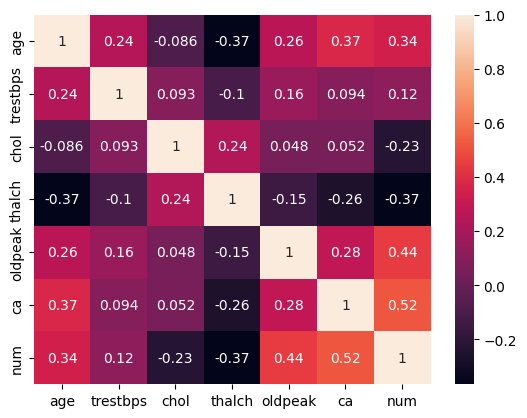

In [32]:
plt.Figure()
sns.heatmap(corr_matriz, annot=True)

### Hallazgos de la matriz de correlación (Pearson)

El análisis de correlación entre variables numéricas muestra que la severidad de la enfermedad cardíaca (num) se asocia principalmente con:

- ca (r = 0.52): correlación positiva moderada–fuerte.
- oldpeak (r = 0.44): correlación positiva moderada.
- thalch (r = -0.37): correlación negativa moderada.
- age (r = 0.34): correlación positiva moderada.

Esto sugiere que una mayor cantidad de vasos principales afectados (ca) y una mayor oldpeak se relacionan con mayor severidad de enfermedad. Por el contrario, una menor frecuencia cardíaca máxima alcanzada (thalch) se asocia con mayor severidad.

Las variables trestbps (r = 0.12) y chol (r = -0.23) muestran correlaciones débiles con la severidad, indicando baja relación lineal en este dataset.

No se observan correlaciones altas (> 0.70) entre variables predictoras, lo que sugiere ausencia de multicolinealidad fuerte entre las variables numéricas analizadas.

In [71]:
# probabilidad general:

data["target"] = (data["num"] >= 1).astype(int)
data["target"].mean()

np.float64(0.5532608695652174)

In [57]:
#probabilidad por sexo:
data.groupby("sex")["target"].mean()


sex
Female    0.257732
Male      0.632231
Name: target, dtype: float64

In [55]:
# oldpeak > 1
print("La probabilidad si tiene depresión del segmento ST inducida por el ejercicio en relación con el reposo (oldpeak) mayor a 1, es de: ",data.loc[data["oldpeak"] > 1, "target"].mean().round(2),"% ")

# thalch < 120
print("La probabilidad si tiene frecuencia cardíaca máxima alcanzada (thalch) menor a 120, es de: ",data.loc[data["thalch"] < 120, "target"].mean().round(2),"% ")

# ca >= 1
print("La probabilidad si tiene número de vasos principales coloreados por fluoroscopia (ca) mayor o igual a 1, es de: ",data.loc[data["ca"] >= 1, "target"].mean().round(2),"% ")

# chol > 240
print("La probabilidad si tiene colesterol sérico (chol) mayor o igual a 1, es de: ",data.loc[data["chol"] > 240, "target"].mean().round(2),"% ")

La probabilidad si tiene depresión del segmento ST inducida por el ejercicio en relación con el reposo (oldpeak) mayor a 1, es de:  0.79 % 
La probabilidad si tiene frecuencia cardíaca máxima alcanzada (thalch) menor a 120, es de:  0.77 % 
La probabilidad si tiene número de vasos principales coloreados por fluoroscopia (ca) mayor o igual a 1, es de:  0.75 % 
La probabilidad si tiene colesterol sérico (chol) mayor o igual a 1, es de:  0.54 % 


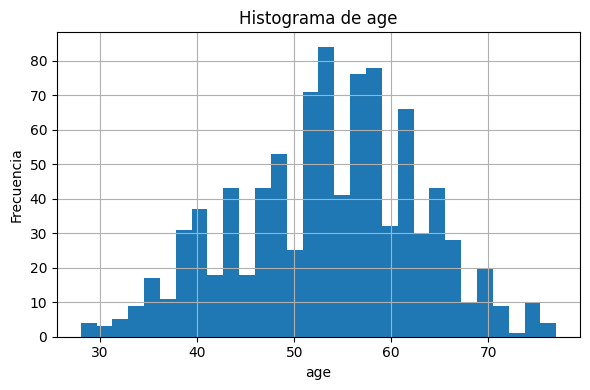

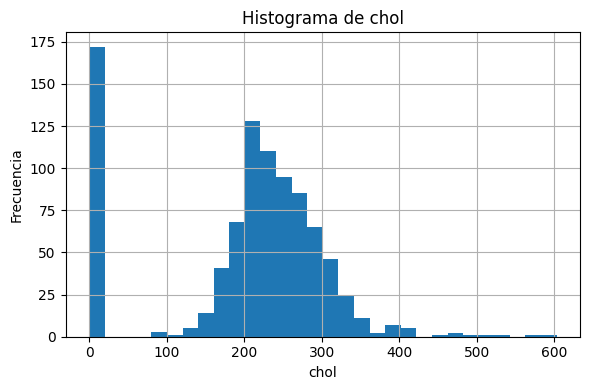

In [62]:
#Histograma para age y chol
for feat in ["age", "chol"]:
    plt.figure(figsize=(6,4))
    data[feat].dropna().hist(bins=30)
    plt.title(f"Histograma de {feat}")
    plt.xlabel(feat)
    plt.ylabel("Frecuencia")
    plt.tight_layout()

In [67]:
# Se cambian los valores 0 en 'chol' por NaN,
# porque un colesterol de 0 no es posible.
# Esos 0 probablemente representan datos faltantes.
data["chol"] = data["chol"].replace(0, np.nan)

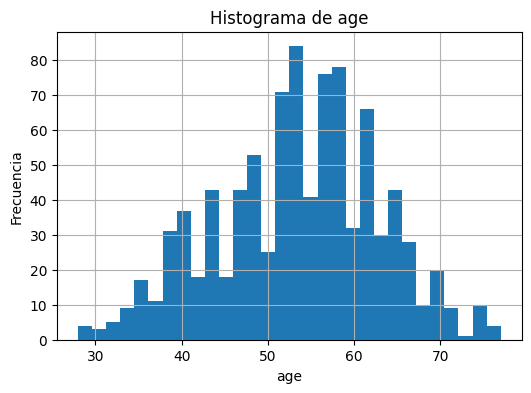

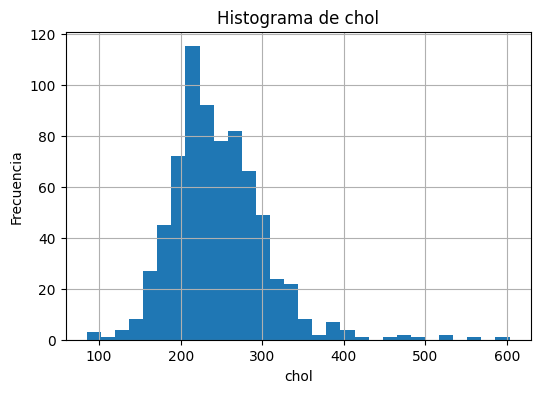

In [75]:
#Histograma para age y chol
for c in ["age", "chol"]:
    plt.figure(figsize=(6,4))
    data[c].dropna().hist(bins=30)
    plt.title(f"Histograma de {c}")
    plt.xlabel(c)
    plt.ylabel("Frecuencia")

### Hallazgos de los histogramas

**Edad (age)**  
La mayoría de las personas en el dataset tiene entre 45 y 65 años, con mayor concentración alrededor de los 50–60 años. Hay pocos casos muy jóvenes o muy mayores, por lo que la muestra representa principalmente adultos de mediana edad.

**Colesterol (chol)**  
La mayor parte de los valores de colesterol se encuentra entre 180 y 300. También aparecen algunos valores bastante altos (por encima de 400), aunque son pocos casos.  

Los valores iguales a 0 fueron tratados como datos faltantes, ya que no representan una medición real dentro del contexto del análisis. Al hacerlo, la distribución del colesterol se observa más consistente.

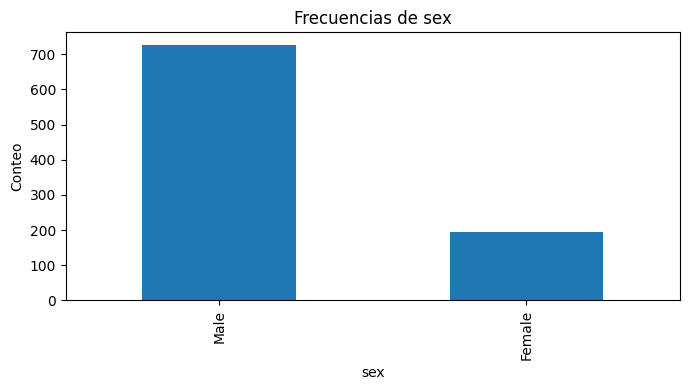

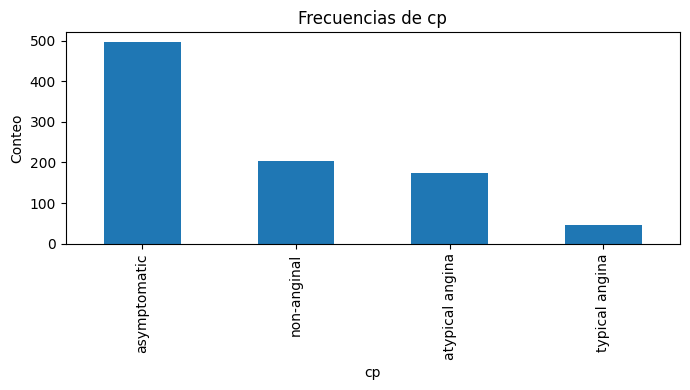

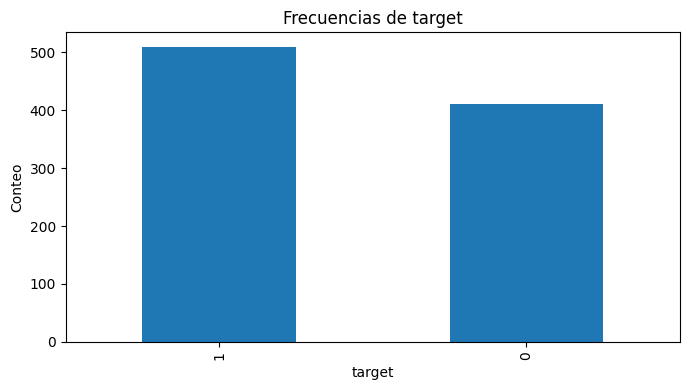

In [ ]:
#Diagramas de caja
for c in ["sex", "cp", "target"]:
    plt.figure(figsize=(7,4))
    data[c].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Frecuencias de {c}")
    plt.xlabel(c)
    plt.ylabel("Conteo")
    plt.tight_layout()

### Hallazgos de las variables categóricas

**Sexo (sex)**  
La muestra está compuesta mayoritariamente por hombres. La cantidad de hombres es considerablemente mayor que la de mujeres, lo que indica un desbalance en la distribución por sexo dentro del dataset.

**Tipo de dolor torácico (cp)**  
La categoría más frecuente es *asymptomatic*, seguida por *non-anginal* y *atypical angina*. La categoría menos frecuente es *typical angina*. Esto muestra que la mayoría de los pacientes no presentaba el dolor torácico clásico, sino otros tipos o incluso ausencia de síntomas típicos.

**Target (presencia de enfermedad)**  
Hay una ligera mayoría de pacientes con enfermedad (target = 1) frente a los que no la presentan (target = 0). Sin embargo, la diferencia no es extrema, por lo que el dataset se encuentra relativamente equilibrado para un análisis binario.

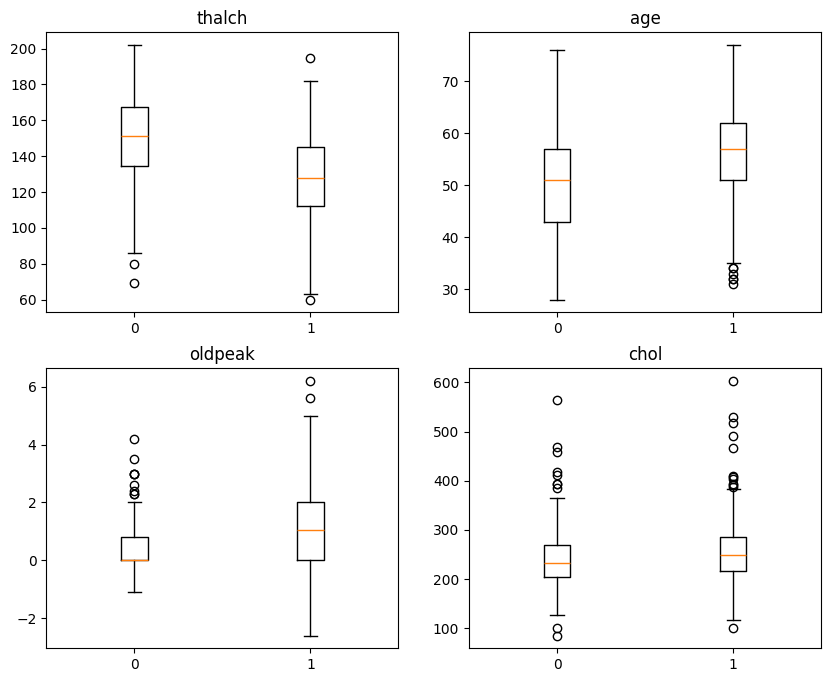

In [78]:
cols = ["thalch", "age", "oldpeak", "chol"]

plt.figure(figsize=(10, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot([
        data.loc[data["target"] == 0, col].dropna(),
        data.loc[data["target"] == 1, col].dropna()
    ])
    plt.title(col)
    plt.xticks([1, 2], ["0", "1"])

### Hallazgos de los boxplots por target

**Frecuencia cardíaca máxima (thalch)**  
Los pacientes con enfermedad (1) muestran valores más bajos en comparación con los que no presentan enfermedad (0). La mediana es menor y la distribución está desplazada hacia abajo, lo que sugiere que alcanzar una menor frecuencia cardíaca máxima se asocia con mayor presencia de enfermedad.

**Edad (age)**  
Los pacientes con enfermedad tienden a ser mayores. La mediana del grupo con enfermedad es más alta y la mayoría de sus valores se concentran en edades superiores en comparación con el grupo sin enfermedad.

**Oldpeak**  
Se observa una diferencia clara entre grupos. Los pacientes con enfermedad presentan valores más altos de oldpeak, mientras que en el grupo sin enfermedad la mayoría de valores se concentran cerca de 0. Es una de las variables donde se nota mayor separación entre ambos grupos.

**Colesterol (chol)**  
Aunque los pacientes con enfermedad muestran una mediana ligeramente mayor, existe bastante superposición entre ambos grupos. Además, se observan varios valores altos en ambos casos, por lo que la diferencia no es tan marcada como en otras variables.

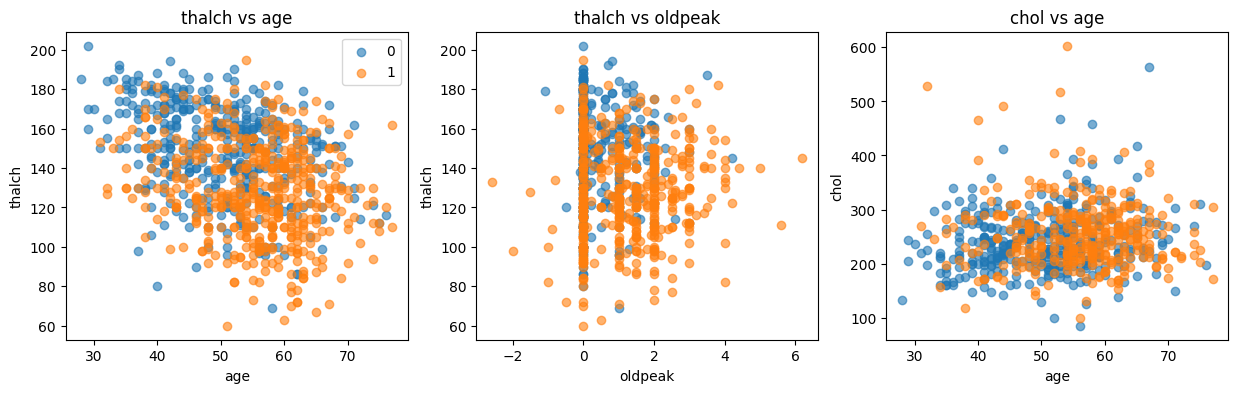

In [82]:
pairs = [
    ("age", "thalch"),
    ("oldpeak", "thalch"),
    ("age", "chol")
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (x, y) in zip(axes, pairs):
    
    ax.scatter(
        data.loc[data["target"] == 0, x],
        data.loc[data["target"] == 0, y],
        alpha=0.6,
        label="0"
    )
    
    ax.scatter(
        data.loc[data["target"] == 1, x],
        data.loc[data["target"] == 1, y],
        alpha=0.6,
        label="1"
    )
    
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")

axes[0].legend();

### Hallazgos de los scatterplots

**Edad vs Frecuencia cardíaca máxima (age vs thalch)**  
Se observa una tendencia general en la que, a mayor edad, la frecuencia cardíaca máxima tiende a disminuir. Además, los pacientes con enfermedad (1) se concentran más en la zona de menor frecuencia cardíaca, lo que sugiere que valores bajos de thalch están asociados con mayor presencia de enfermedad.

**Oldpeak vs Frecuencia cardíaca máxima (oldpeak vs thalch)**  
Los pacientes con enfermedad muestran valores más altos de oldpeak y, al mismo tiempo, frecuencias cardíacas máximas más bajas. Aunque existe superposición entre ambos grupos, se aprecia una mayor concentración de casos con enfermedad en zonas donde oldpeak es alto.

**Edad vs Colesterol (age vs chol)**  
En este gráfico no se observa una separación clara entre pacientes con y sin enfermedad. Ambos grupos se mezclan ampliamente, lo que sugiere que la combinación de edad y colesterol, por sí sola, no permite distinguir fácilmente entre los dos grupos.

En conjunto, las combinaciones que incluyen **thalch y oldpeak** muestran una diferenciación más evidente entre grupos que aquellas que incluyen colesterol.